# Physical Activity - ENMO Analysis 
**GitHub repository:* [Our GitHub repository](https://github.com/Aminata-MOUSSA/HAH913E-Physical-Activity-00.git)

**Team member:**
- Ndiaya DIENG
- Aminata MOUSSA
- Ifetayo HOUESSIONON 
- Noam GREA 

## Objectif

Ce notebook présente l’analyse de données brutes d’accélérométrie enregistrées avec un accéléromètre Axivity AX3 porté au poignet non dominant. L’ENMO sera calculé à partir des trois axes d’accélération (`x`, `y`, `z`), puis intégré sur des périodes de 10, 30 et 60 secondes.

## 1. Importer les bibliothèques

**Objectif :** charger les outils nécessaires pour lire et analyser les données.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

`pandas` sert à lire et manipuler les tableaux. `numpy` sert aux calculs numériques. `matplotlib` sera utilisé plus tard pour les graphiques.

## 2. Importer les données

**Objectif :** lire le fichier CSV et vérifier rapidement son contenu.

In [78]:
df= pd.read_csv("0_z.csv", comment="#")
df.head()

,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


Le fichier commence par une ligne de commentaire qui indique l’unité des mesures. L’option `comment="#"` demande à pandas de l’ignorer. Les données sont chargées dans `df`, un tableau appelé DataFrame. `df.head()` affiche ses cinq premières lignes.

## 3. Vérifier les données

### Étape 1 : regarder la taille et les colonnes

**Objectif :** comprendre combien de mesures contient le fichier et identifier les colonnes.

In [79]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Column names:", list(df.columns))
df.head()

Number of rows: 21000
Number of columns: 4
Column names: ['t', 'x', 'y', 'z']


,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


`df.shape[0]` donne le nombre de lignes, `df.shape[1]` le nombre de colonnes, et `df.columns` leurs noms.

### Étape 2 : vérifier les colonnes nécessaires

**Objectif :** s’assurer que le temps (`t`) et les trois axes (`x`, `y`, `z`) sont présents.

In [80]:
required_columns = ["t", "x", "y", "z"]
missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are present:", required_columns)

All required columns are present: ['t', 'x', 'y', 'z']


Si une colonne manque, `raise ValueError` arrête le code et affiche un message d’erreur.

### Étape 3 : vérifier les types et les valeurs manquantes

**Objectif :** vérifier que les mesures sont numériques et qu’aucune valeur ne manque.

In [81]:
print("Original data types:")
print(df[required_columns].dtypes)

df[required_columns] = df[required_columns].apply(pd.to_numeric, errors="coerce")
missing_values = df[required_columns].isna().sum()

print("Missing or non-numeric values:")
print(missing_values)

if missing_values.any():
    raise ValueError("Some required values are missing or non-numeric.")

Original data types:
t    float64
x    float64
y    float64
z    float64
dtype: object
Missing or non-numeric values:
t    0
x    0
y    0
z    0
dtype: int64


`pd.to_numeric()` convertit les valeurs en nombres. Avec `errors="coerce"`, une valeur impossible à convertir devient manquante. `isna().sum()` compte les valeurs manquantes dans chaque colonne.

Pour ce fichier, les colonnes `t`, `x`, `y` et `z` sont toutes de type `float64`. Cela signifie que les valeurs sont des nombres à virgule, comme `0.02`, enregistrés avec une précision de 64 bits. Le contrôle trouve **0 valeur manquante** dans chacune des quatre colonnes.

### Étape 4 : vérifier l’ordre du temps

**Objectif :** vérifier que les temps sont dans l’ordre et ne sont pas répétés.

In [82]:
time_is_increasing = df["t"].is_monotonic_increasing
duplicate_times = df["t"].duplicated().sum()

print("Time is increasing:", time_is_increasing)
print("Duplicate time values:", duplicate_times)

if not time_is_increasing or duplicate_times > 0:
    raise ValueError("The time column must increase without duplicate values.")

Time is increasing: True
Duplicate time values: 0


`is_monotonic_increasing` vérifie que les temps avancent dans l’ordre. `duplicated().sum()` compte les temps répétés.

## 4. Calculer la fréquence d’échantillonnage

**Objectif :** déterminer le nombre de mesures enregistrées chaque seconde et vérifier la régularité des mesures.

### Étape 1 : calculer le temps entre deux mesures

In [83]:
time_intervals = df["t"].diff().dropna()

if time_intervals.empty:
    raise ValueError("At least two time measurements are required.")

time_intervals.head()

1    0.02
2    0.02
3    0.02
4    0.02
5    0.02
Name: t, dtype: float64

`diff()` calcule l’écart de temps entre deux mesures consécutives. `dropna()` retire le premier résultat, car il n’a pas de mesure précédente.

### Étape 2 : trouver l’intervalle typique

In [84]:
dt = time_intervals.median()
print(f"Typical time interval: {dt:.4f} s")

Typical time interval: 0.0200 s


La médiane des intervalles est stockée dans `dt`. Pour notre fichier, elle vaut **0,02 seconde**.

### Étape 3 : calculer la fréquence

In [85]:
fs = 1 / dt
print(f"Sampling frequency: {fs:.2f} Hz")

Sampling frequency: 50.00 Hz


La fréquence est l’inverse de l’intervalle : $fs = 1 / dt$. Notre fréquence est de **50 Hz**, soit 50 mesures par seconde.

### Étape 4 : vérifier la régularité

In [86]:
irregular_count = int(
    (~np.isclose(time_intervals, dt, rtol=1e-3, atol=1e-9)).sum()
)
print(f"Irregular intervals: {irregular_count} / {len(time_intervals)}")

Irregular intervals: 0 / 20999


`np.isclose()` compare chaque intervalle à l’intervalle typique et tolère de petits écarts dus aux arrondis. Le fichier contient **0 intervalle irrégulier sur 20 999**.

## ENMO calculation 
L'ENMO (Euclidean Norm Minus One) est calculé à partir des trois axes d'accélération (x, y et z).

La norme euclidienne permet d'obtenir la magnitude du vecteur d'accélération. On soustrait ensuite 1 g afin de retirer la contribution de la gravité.

ENMO = √(x² + y² + z²) - 1

On a crée une fonction nous permettant de calculer l'ENMO :
celle-ci prend en entrée les valeurs des axes x,y,z et renvoie en sortie l'ENMO qui a été calculé. 

In [87]:
def calculate_enmo(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2) - 1

Ici on décide de stocker les résultats des calculs précédents  dans une nouvelle colonne appelée "enmo" dans notre DataFrame df.

In [88]:
df["enmo"] = calculate_enmo(df["x"], df["y"], df["z"])

In [89]:
df[["t", "enmo"]].head()

,t,enmo
0,0.00,-0.042168
1,0.02,-0.042168
2,0.04,-0.042168
3,0.06,-0.042168
4,0.08,-0.042168


## Intégration de l'ENMO par epoch

Afin d'étudier l'activité physique sur différentes durées, les valeurs d'ENMO sont intégrées sur des epochs de 10, 30 et 60 secondes.

Le nombre d'échantillons correspondant à un epoch dépend de la fréquence d'échantillonnage. Les valeurs d'ENMO appartenant au même epoch sont regroupées puis additionnées. Le résultat est ensuite exprimé en g·min.

Une fonction est créée afin de calculer l'ENMO intégré sur une durée d'epoch définie.

Elle prend en entrée le DataFrame contenant les valeurs d'ENMO (`df`), la durée de l'epoch en secondes (`epoch`) et la fréquence d'échantillonnage (`fs`).

La fonction regroupe les valeurs d'ENMO selon la durée de l'epoch choisie et retourne les valeurs d'ENMO intégré obtenues pour chaque intervalle.

In [90]:
def calculate_integrated_enmo(df, epoch, fs):
    samples = int(fs * epoch)

    integrated_enmo = (
        df["enmo"]
        .groupby(df.index // samples)
        .sum()
        / fs
        / 60
    )

    return integrated_enmo

In [91]:
integrated_enmo_10s = calculate_integrated_enmo(df, 10, fs)
integrated_enmo_30s = calculate_integrated_enmo(df, 30, fs)
integrated_enmo_60s = calculate_integrated_enmo(df, 60, fs)

print("Number of 10 s epochs:", len(integrated_enmo_10s))
print("Number of 30 s epochs:", len(integrated_enmo_30s))
print("Number of 60 s epochs:", len(integrated_enmo_60s))

Number of 10 s epochs: 42
Number of 30 s epochs: 14
Number of 60 s epochs: 7


## ENMO Visualization
### Raisonnement :
Ici nous appliquons une **intégration temporelle par époque** sur trois durées différentes : **10 secondes, 30 secondes et 60 secondes**. 

L'intégration consiste à sommer les valeurs d'ENMO sur chaque fenêtre de temps et à exprimer le résultat en $g\cdot\text{min}. Cela permet de lisser le signal, de réduire le bruit de mesure et d'observer l'impact de la résolution temporelle sur l'analyse.

### Fonction d'intégration par époque :

La fonction ci-dessous découpe le signal en fonction de la fréquence d'échantillonnage ($f_s$) et de la durée de l'époque (10 s, 30 s ou 60 s) choisie, puis regroupe les échantillons par blocs temporels pour en sommer l'intensité.

### Description détaillée de la fonction de visualisation (`plot_enmo_analysis`)

 Son exécution se décompose en plusieurs étapes clés :

* **1. Calcul et récupération de l'ENMO intégrée** :
La fonction commence par appeler la fonction de calcul de l'équipe (`calculate_integrated_enmo`) pour agréger les valeurs d'ENMO sur la fenêtre temporelle choisie, obtenant ainsi l'aire sous la courbe par époque (exprimée en $g\cdot\text{min}$).
* **2. Préparation des axes temporels en minutes** :
* `time_min = df["t"] / 60.0` convertit le temps brut en secondes en minutes pour l'axe horizontal du graphique inférieur.
* `time_epoch` calcule le positionnement temporel des barres en fonction de la durée de l'époque (`epoch_min`).


* **3. Initialisation d'une figure à deux panneaux** :
À l'aide de `plt.subplots(2, 1, sharex=True, dpi=100)`, on crée une figure verticale contenant deux sous-graphes (`ax[0]` et `ax[1]`) qui partagent exactement le même axe des abscisses pour faciliter la comparaison visuelle.
* **4. Tracé du sous-graphe supérieur (Diagramme en barres)** :
* `ax[0].bar(...)` dessine les valeurs de l'ENMO intégrée sous forme de barres grises (`color="darkgray"`).
* L'utilisation de `align="edge"` et d'une largeur de barre légèrement réduite (`width=epoch_min * 0.95`) permet d'espacer proprement chaque période.
* Le titre du graphique s'adapte automatiquement à la durée de l'époque testée (`f"ENMO integrated over {epoch:.1f} s intervals"`).


* **5. Tracé du sous-graphe inférieur (Courbe continue du signal brut)** :
* `ax[1].plot(...)` trace l'ENMO brute au fil du temps en bleu (`#1f77b4`).
* Un paramètre de transparence (`alpha=0.55`) et une faible épaisseur de ligne (`linewidth=0.8`) sont appliqués pour que les variations rapides et les pics d'activité restent parfaitement lisibles.


* **6. Mise en page et retour des résultats** :
* `plt.tight_layout()` ajuste automatiquement l'espacement des éléments pour éviter toute superposition visuelle.
* `plt.show()` affiche la figure finale à l'écran, et la fonction retourne la série de données `integrated_enmo`.

In [92]:
# 1. Définition de la fonction pour tracer les graphiques conformément aux attentes
def plot_enmo_analysis(df, epoch, fs):
    """
    Génère la figure à deux sous-graphes :
    - En haut : l'ENMO intégrée (g.min) en diagramme en barres grises.
    - En bas : l'ENMO brute au cours du temps (en minutes).
    """
    # Utilisation de la fonction de l'ENMO intégrée
    integrated_enmo = calculate_integrated_enmo(df, epoch, fs)

    time_min = df["t"] / 60.0
    epoch_min = epoch / 60.0
    time_epoch = np.arange(len(integrated_enmo)) * epoch_min

    fig, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True, dpi=100)

    # Graphique du haut (Barres)
    ax[0].bar(
        time_epoch,
        integrated_enmo,
        width=epoch_min * 0.95,
        align="edge",
        color="darkgray",
    )
    ax[0].set_title(f"ENMO integrated over {epoch:.1f} s intervals", fontsize=11)
    ax[0].set_ylabel("Integrated ENMO (g.min)", fontsize=9)
    ax[0].tick_params(axis="both", which="major", labelsize=9)

    # Graphique du bas (Courbe continue)
    ax[1].plot(time_min, df["enmo"], color="#1f77b4", alpha=0.55, linewidth=0.8)
    ax[1].set_title("ENMO over Time", fontsize=11)
    ax[1].set_xlabel("Time (minutes)", fontsize=9)
    ax[1].set_ylabel("ENMO (g)", fontsize=9)
    ax[1].tick_params(axis="both", which="major", labelsize=9)
    ax[1].set_xlim(-0.3, max(7.2, time_min.max() + 0.2))

    plt.tight_layout()
    plt.show()

    return integrated_enmo


### Fonction de tracé des graphiques comparatifs :
Pour répondre aux critères visuels du sujet, nous concevons une fonction modulaire qui génère une figure à **deux sous-graphes superposés** partageant le même axe horizontal (le temps en minutes):

1. **Le Diagramme en barres** : Affiche l'ENMO intégrée en $g\cdot\text{min}$ sous forme de barres grises (`darkgray`), 
2. **La Courbe continue** : Affiche l'ENMO brute au cours du temps en bleu (`#1f77b4`) 

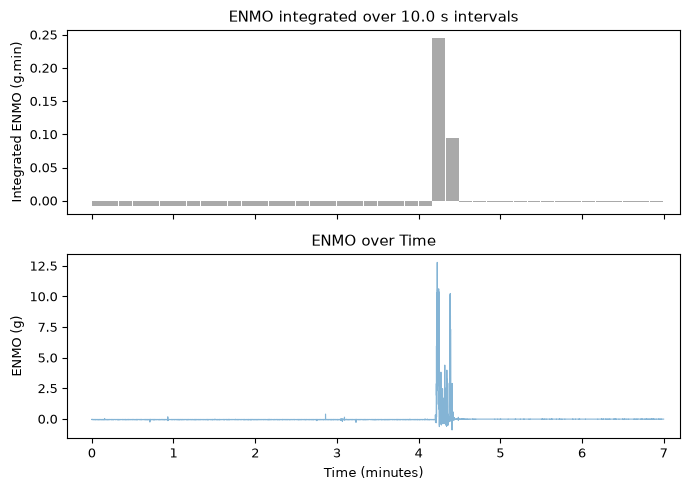

In [93]:
integrated_10s = plot_enmo_analysis(df, 10.0, fs)

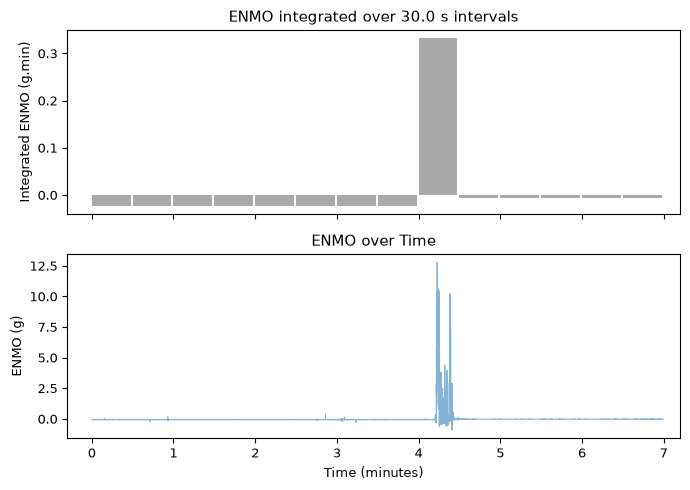

In [94]:
integrated_30s = plot_enmo_analysis(df, 30.0, fs)

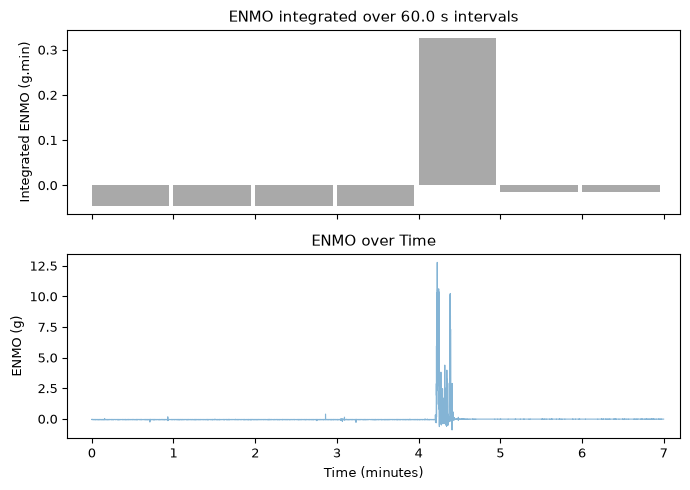

In [95]:
integrated_60s = plot_enmo_analysis(df, 60.0, fs)

# Comparaison avec le code donné par Copilot

## Code de Copilot


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Charger les données
# -----------------------------
df = pd.read_csv('0_z.csv')

# Colonnes : t (sec), x, y, z (g)
t = df['t'].values
x = df['x'].values
y = df['y'].values
z = df['z'].values

# -----------------------------
# 2. Calcul ENMO
# -----------------------------
mag = np.sqrt(x**2 + y**2 + z**2)
enmo = np.maximum(mag - 1, 0)

df['ENMO'] = enmo

# -----------------------------
# 3. Fonction pour intégrer ENMO par epoch
# -----------------------------
def integrate_enmo(df, epoch_length):
    results = []
    t = df['t'].values
    enmo = df['ENMO'].values

    start = t[0]
    end = t[-1]

    epoch_start = start

    while epoch_start < end:
        epoch_end = epoch_start + epoch_length

        mask = (t >= epoch_start) & (t < epoch_end)
        enmo_epoch = enmo[mask]

        if len(enmo_epoch) > 0:
            dt = np.mean(np.diff(t[mask]))
            enmo_int = np.sum(enmo_epoch * dt)
            results.append([epoch_start, enmo_int])

        epoch_start = epoch_end

    return pd.DataFrame(results, columns=['epoch_start', 'enmo_integrated'])

epochs = {
    '10s': integrate_enmo(df, 10),
    '30s': integrate_enmo(df, 30),
    '60s': integrate_enmo(df, 60)
}

plt.figure(figsize=(12, 6))

for label, ep_df in epochs.items():
    plt.plot(ep_df['epoch_start'], ep_df['enmo_integrated'], label=label)

plt.title('ENMO intégré par epoch')
plt.xlabel('Temps (s)')
plt.ylabel('ENMO intégré')
plt.legend()
plt.grid(True)
plt.show()


## Comparaison

Le code proposé par Copilot n'ignore pas les lignes commençant par `#` lors de la lecture du fichier CSV. Il ne vérifie pas non plus la forme du jeu de données. Copilot ne calcule pas la fréquence car il ne suppose pas la régularité des données.

Copilot met les valeurs négatives à 0 pour suivre la définition scientifique standard du ENMO. Il conserve les unités en `g.s` au lieu de les convertir en `g.min`. Il ne sépare pas le ENMO brut et le ENMO intégré.

Copilot propose ainsi un code plus rigoureux et plus rapide, mais moins structuré. Il conserve systématiquement la contrainte `ENMO ≥ 0`.